In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

from matplotlib import dates

In [2]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)

In [3]:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [4]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [5]:
def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [6]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    overlaps_ranked = rank_overlaps(start, end, sci_query)
    
    for index in overlaps_ranked[:,1]:
        badrange=False
        sci_files = Fido.fetch(sci_query[0][int(index)])
        sci_data = Product(sci_files)
    
        if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
            badrange=True
        
        if not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [7]:
indices_array = np.array(indices)
incomplete_file_ind = [5, 18, 26, 29]

In [8]:
for ind in incomplete_file_ind:
    sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[ind], top100['end_UTC'].iloc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    sci_query

    sci_files = Fido.fetch(sci_query)
    sci_files = sorted(sci_files)
    
    
    sci_data_A = Product(sci_files[0])
    sci_data_B = Product(sci_files[1])
    
    df_A = get_stix_df(sci_data_A, energy_ranges)
    df_B = get_stix_df(sci_data_B, energy_ranges)
    
    combined_df = pd.concat([df_A, df_B])
    
    combined_df = combined_df.sort_index()
    
    df = combined_df[~combined_df.index.duplicated(keep="first")]

    df_list[ind]=df

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [9]:
exclude = [26, 33, 35, 36, 55, 56, 58, 59, 61, 66, 70, 73, 77, 80, 83, 90, 96]

In [10]:
df_list_refined = df_list.copy()
for ind in indices:
    if ind in exclude:
        df_list_refined[ind]='excluded'

indices_refined = list(set(indices)-set(top100.index[exclude]))

In [11]:
df_list_filtered = []
for loc, ind in enumerate(indices):
    if ind in indices_refined:
        df_filtered  = df_list[loc].copy()
        
        filtered_2550 = savgol_filter(df_list[loc]['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
        filtered_50100 = savgol_filter(df_list[loc]['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

        df_filtered['25.0 keV-50.0 keV'] = filtered_2550
        df_filtered['50.0 keV-100.0 keV'] = filtered_50100

        df_list_filtered.append(df_filtered)
        
    if ind not in indices_refined:
        df_list_filtered.append('excluded')
        

In [12]:
columns = ('flare_list_id', 'start_time', 'end_time','peak_time', 'peak_counts', 'number_of_peaks', 'duration','rise_time', 'decay_time','start_time (50-100 keV)', 'end_time (50-100 keV)', 'peak_counts (50-100 keV)', 'rise_time (50-100 keV)', 'decay_time (50-100 keV)', 'FWHM (25-50 keV)', 'FWHM (50-100 keV)', 'comments')
data=np.zeros((len(indices_refined), len(columns)))
filtered_stats_df = pd.DataFrame(data, columns = columns)

In [13]:
filtered_stats_df['flare_list_id'] = filtered_stats_df['flare_list_id'].astype(int)
label = 0
for loc, ind in enumerate(indices):
    if loc not in exclude:
        filtered_stats_df.loc[label, 'flare_list_id'] = int(ind)
        label+=1

In [14]:
filtered_stats_df['start_time'] = filtered_stats_df['start_time'].astype(str)
filtered_stats_df['end_time'] = filtered_stats_df['end_time'].astype(str)
filtered_stats_df['rise_time'] = filtered_stats_df['rise_time'].astype(str)
filtered_stats_df['decay_time'] = filtered_stats_df['decay_time'].astype(str)
filtered_stats_df['peak_time'] = filtered_stats_df['peak_time'].astype(str)
filtered_stats_df['start_time (50-100 keV)'] = filtered_stats_df['start_time (50-100 keV)'].astype(str)
filtered_stats_df['end_time (50-100 keV)'] = filtered_stats_df['end_time (50-100 keV)'].astype(str)
filtered_stats_df['rise_time (50-100 keV)'] = filtered_stats_df['rise_time (50-100 keV)'].astype(str)
filtered_stats_df['decay_time (50-100 keV)'] = filtered_stats_df['decay_time (50-100 keV)'].astype(str)

In [15]:
label=0
i=0
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
    
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
        plot_df = sci_df.truncate(start, end)
        plot_df.index = parse_time(plot_df.index).datetime 
        
        r = top100['solo_position_AU_distance'].loc[ind]

        peak_counts = np.max(plot_df['25.0 keV-50.0 keV'])
        peak_counts_scaled = peak_counts/r**2
        filtered_stats_df.loc[label, 'peak_counts'] = peak_counts_scaled
        peak_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] == peak_counts][0]
        filtered_stats_df.loc[label, 'peak_time'] = str(peak_loc)

        flare = plot_df[plot_df['25.0 keV-50.0 keV']>10/r**2]
        tstart = flare.index[0]
        tend = plot_df[(plot_df['25.0 keV-50.0 keV']<10/r**2) & (plot_df.index>peak_loc)].index[0]

        filtered_stats_df.loc[label, 'start_time'] = str(tstart)
        filtered_stats_df.loc[label, 'end_time'] = str(tend)
        
        plot_df = plot_df.truncate(t(tstart), t(tend))

        rise_time = peak_loc - tstart
        decay_time = tend - peak_loc
        filtered_stats_df.loc[label, 'rise_time'] = str(rise_time).split(" ")[-1]
        filtered_stats_df.loc[label, 'decay_time'] = str(decay_time).split(" ")[-1]

        duration = (t(tend) - t(tstart)).total_seconds()
        filtered_stats_df.loc[label, 'duration'] = duration

        peak_counts_50_100 = np.max(plot_df['50.0 keV-100.0 keV'])
        peak_counts_50_100_scaled = peak_counts_50_100/r**2
        filtered_stats_df.loc[label, 'peak_counts (50-100 keV)'] = peak_counts_50_100_scaled
        peak_loc_50_100 = plot_df.index[plot_df['50.0 keV-100.0 keV'] == peak_counts_50_100][0]

        flare_50_100 = plot_df[plot_df['50.0 keV-100.0 keV']>3/r**2]

        if flare_50_100.empty:
            filtered_stats_df.loc[label, 'rise_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'decay_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'start_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'end_time (50-100 keV)'] = np.nan
        
        else:
            tstart_50_100 = flare_50_100.index[0]
            #tend_50_100 = flare_50_100.index[-1]
            # tend_50_100 = plot_df[(plot_df['50.0 keV-100.0 keV']<3/r**2) & (plot_df.index>peak_loc_50_100)]
            # if tend_50_100.empty:
            #     findend = plot_df[(plot_df.index>peak_loc_50_100)&(plot_df.index<t(tend))]
            #     tend_50_100 = findend.index[findend['50.0 keV-100.0 keV'] == np.min(findend['50.0 keV-100.0 keV'])][-1]
            # else:
                #tend_50_100 = tend_50_100.index[0]
            tend_50_100 = flare_50_100.index[-1]

            rise_time_50_100 = peak_loc_50_100 - tstart_50_100
            decay_time_50_100 = tend_50_100 - peak_loc_50_100
            filtered_stats_df.loc[label, 'rise_time (50-100 keV)'] = str(rise_time_50_100).split(" ")[-1]
            filtered_stats_df.loc[label, 'decay_time (50-100 keV)'] = str(decay_time_50_100).split(" ")[-1]
            filtered_stats_df.loc[label, 'start_time (50-100 keV)'] = str(tstart_50_100)
            filtered_stats_df.loc[label, 'end_time (50-100 keV)'] = str(tend_50_100)

        peaks, properties = find_peaks(plot_df['25.0 keV-50.0 keV'], distance=30, prominence=0.1*peak_counts)
        filtered_stats_df.loc[label, 'number_of_peaks'] = len(peaks)
        #peak_locs[label]=peaks

        label+=1
    i+=1

In [16]:
label=0
i=0
half_max_points = []
half_max_vals = []
end_points = []
end_point_vals = []
fwhm_list = []
half_max_points_50100 = []
half_max_vals_50100 = []
end_points_50100 = []
end_point_vals_50100 = []
fwhm_list_50100 = []
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
    
        tstart = filtered_stats_df['start_time'].iloc[label]
        tend = filtered_stats_df['end_time'].iloc[label]
        tpeak = filtered_stats_df['peak_time'].iloc[label]

        r = top100['solo_position_AU_distance'].loc[ind]
        max_counts = (filtered_stats_df['peak_counts'].iloc[label])*r**2

        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))

        half_max = 0.5*max_counts
        half_max_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] >= half_max][0]
        half_max_points.append(half_max_loc)
        half_max_vals.append(half_max)

        over_half = np.where(plot_df['25.0 keV-50.0 keV']>half_max)
        end_point = plot_df.index[over_half[0][-1]]
        end_points.append(end_point)
        end_point_vals.append(plot_df['25.0 keV-50.0 keV'].iloc[over_half[0][-1]])

        # rise_time_50_100_td = pd.to_timedelta(filtered_stats_df['rise_time (50-100 keV)'])
        # decay_time_50_100_td = pd.to_timedelta(filtered_stats_df['decay_time (50-100 keV)'])
        
        # durations_50_100 = rise_time_50_100_td+decay_time_50_100_td
        # durations_50_100 = durations_50_100.dt.total_seconds()

        fwhm = (t(end_point)-t(half_max_loc))
            #.total_seconds()
        fwhm_list.append(fwhm)

        filtered_stats_df.loc[label, 'FWHM (25-50 keV)'] = fwhm.total_seconds()

        if pd.notna(filtered_stats_df['start_time (50-100 keV)'].iloc[label]):
            max_counts_50100 = (filtered_stats_df['peak_counts (50-100 keV)'].iloc[label])*r**2
    
            half_max_50100 = 0.5*max_counts_50100
            half_max_loc_50100 = plot_df.index[plot_df['50.0 keV-100.0 keV'] >= half_max_50100][0]
            half_max_points_50100.append(half_max_loc_50100)
            half_max_vals_50100.append(half_max_50100)
    
            over_half_50100 = np.where(plot_df['50.0 keV-100.0 keV']>half_max_50100)
            end_point_50100 = plot_df.index[over_half_50100[0][-1]]
            end_points_50100.append(end_point_50100)
            end_point_vals_50100.append(plot_df['50.0 keV-100.0 keV'].iloc[over_half_50100[0][-1]])
            
            fwhm_50100 = (t(end_point_50100)-t(half_max_loc_50100))
                #.total_seconds()
            fwhm_list_50100.append(fwhm_50100)

            filtered_stats_df.loc[label, 'FWHM (50-100 keV)'] = fwhm_50100.total_seconds()

        else:
            filtered_stats_df.loc[label, 'FWHM (50-100 keV)'] = np.nan
            fwhm_list_50100.append(np.nan)
            half_max_vals_50100.append(np.nan)
            half_max_points_50100.append(np.nan)
            end_points_50100.append(np.nan)
            end_point_vals_50100.append(np.nan)
            
        label+=1
    i+=1

In [17]:
df_list_extrafiltered = []
for loc, ind in enumerate(indices):
    if ind in indices_refined:
        df_filtered  = df_list[loc].copy()
        
        filtered_2550 = savgol_filter(df_list[loc]['25.0 keV-50.0 keV'], window_length = 305, polyorder=2)
        filtered_50100 = savgol_filter(df_list[loc]['50.0 keV-100.0 keV'], window_length = 305, polyorder=2)

        df_filtered['25.0 keV-50.0 keV'] = filtered_2550
        df_filtered['50.0 keV-100.0 keV'] = filtered_50100

        df_list_extrafiltered.append(df_filtered)
        
    if ind not in indices_refined:
        df_list_extrafiltered.append('excluded')

In [178]:
bad_diff = [1, 7, 9, 23, 25, 26, 27, 33, 40, 47, 61, 73, 75, 35, 37, 41, 42, 44, 52, 53, 56, 58, 60, 63, 67, 70, 74, 76, 77, 78, 80]
#bad_diff = [1, 7, 9, 23, 25, 26, 27, 33, 40, 47, 61, 73, 75, 35, 37, 41, 42, 44, 52, 53, 56, 58, 60, 63, 67, 70, 74, 76, 77, 78, 80, 11, 12, 19, 30, 32, 38, 66, 81]

In [179]:
durations_diff = []
estimated_starts = []
estimated_ends = []
durations_diff_50100 = []
estimated_starts_50100 = []
estimated_ends_50100 = []
i=0
for ind in indices:
    if ind in indices_refined:
        if i not in bad_diff:
            sci_df = df_list_extrafiltered[np.where(indices_array==ind)[0][0]]

            start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
            end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
        
            plot_df = sci_df.truncate(start, end)
            plot_df.index = parse_time(plot_df.index).datetime 
            #plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
    
            test_df = plot_df[np.abs(plot_df['25.0 keV-50.0 keV'].diff())>0.05]
            diff_estimated_start = test_df.index[0]
            diff_estimated_end = test_df.index[-1]

            estimated_starts.append(diff_estimated_start)
            estimated_ends.append(diff_estimated_end)

            estimated_duration = (diff_estimated_end - diff_estimated_start).total_seconds()
            durations_diff.append(estimated_duration)

            if pd.notna(fwhm_list_50100[i]):
                test_df_50100 = test_df[np.abs(test_df['50.0 keV-100.0 keV'].diff())>0.02]
                diff_estimated_start_50100 = test_df_50100.index[0]
                diff_estimated_end_50100 = test_df_50100.index[-1]
    
                estimated_starts_50100.append(diff_estimated_start_50100)
                estimated_ends_50100.append(diff_estimated_end_50100)
    
                estimated_duration_50100 = (diff_estimated_end_50100 - diff_estimated_start_50100).total_seconds()
                durations_diff_50100.append(estimated_duration_50100)

            else:
                durations_diff_50100.append(np.nan)
                estimated_starts_50100.append(np.nan)
                estimated_ends_50100.append(np.nan)
         
        else:
            durations_diff.append(np.nan)
            estimated_starts.append(np.nan)
            estimated_ends.append(np.nan)
            durations_diff_50100.append(np.nan)
            estimated_starts_50100.append(np.nan)
            estimated_ends_50100.append(np.nan)
        i+=1

In [180]:
# bad_diff_full = [1, 7, 9, 23, 25, 27, 28, 37, 44, 51, 72, 88, 91, 39, 41, 45, 46, 48, 60, 62, 65, 68, 71, 75, 81, 85, 89, 92, 93, 94, 97]
bad_diff_full = [1, 7, 9, 23, 25, 27, 28, 37, 44, 51, 72, 88, 91, 39, 41, 45, 46, 48, 60, 62, 65, 68, 71, 75, 81, 85, 89, 92, 93, 94, 97, 11, 12, 19, 31, 34, 42, 79, 98]

In [181]:
len(df_list)

100

In [182]:
restricted_df_list = []
for i in range(len(df_list_refined)):
    if i not in bad_diff_full+exclude:
        restricted_df_list.append(df_list_refined[i])
len(restricted_df_list)

44

In [183]:
restricted_df_list_50100_a = []
restricted_df_list_50100 = []
for i in range(len(df_list_refined)):
    if pd.notna(df_list_refined[i].all().all()):
        restricted_df_list_50100_a.append(df_list_refined[i])
for i in range(len(durations_diff_50100)):
    if pd.notna(durations_diff_50100[i]):
        restricted_df_list_50100.append(restricted_df_list_50100_a[i])

len(restricted_df_list_50100)

42

In [184]:
estimated_starts_x = []
estimated_ends_x = []
for start in estimated_starts:
    if pd.notna(start):
        estimated_starts_x.append(start)
for end in estimated_ends:
    if pd.notna(end):
        estimated_ends_x.append(end)

In [185]:
restricted_stats_df = filtered_stats_df[~filtered_stats_df.index.isin(bad_diff)]
flarelist = top100[~top100.index.isin(list(top100.index[exclude])+list(top100.index[bad_diff_full]))]

In [186]:
resampled_df_list = []
i=0
for df in restricted_df_list:
    # df_x = df.truncate(estimated_starts_x[i], estimated_starts_x[i]+dt.timedelta(seconds=2377))
    resampled_df = df.resample('1s').mean()
    resampled_df_list.append(resampled_df)
    i+=1

In [187]:
resampled_df_list_50100 = []
for df in restricted_df_list_50100:
    resampled_df = df.resample('1s').mean()
    resampled_df_list_50100.append(resampled_df)

In [188]:
normalised_df_list = []
for df in resampled_df_list:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list.append(normalised_df)

In [189]:
normalised_df_list_50100 = []
for df in resampled_df_list_50100:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = df['25.0 keV-50.0 keV']/np.max(df['25.0 keV-50.0 keV'])
    normalised_df['50.0 keV-100.0 keV'] = df['50.0 keV-100.0 keV']/np.max(df['25.0 keV-50.0 keV'])
    normalised_df_list_50100.append(normalised_df)

In [190]:
timeshifted_df_list = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(estimated_starts_x[i])).round('1s')
    end = pd.to_datetime(t(estimated_ends_x[i])).round('1s')
    #
    
    # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    total_end = (end - dt.datetime(2004, 11, 25)).total_seconds()

    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, 2377)
    timeshifted_df_list.append(timeshifted_df)
    i+=1

In [191]:
timeshifted_df_list_50100 = []
i=0
for df in normalised_df_list_50100:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(estimated_starts_x[i])).round('1s')
    end = pd.to_datetime(t(estimated_ends_x[i])).round('1s')
    #
    
    # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    total_end = (end - dt.datetime(2004, 11, 25)).total_seconds()

    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, 2377)
    timeshifted_df_list_50100.append(timeshifted_df)
    i+=1

In [192]:
# i=0
# for df in restricted_df_list:
#     fig, ax = plt.subplots()

#     plot_df = restricted_df_list[i]
   
#     plot_df.index = parse_time(plot_df.index).datetime
#     plot_df = plot_df.truncate(t(estimated_starts_x[i]), t(estimated_starts_x[i]) + dt.timedelta(seconds=2377))
    
#     for n in range(len(plot_df.columns)):
#         ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    
#     handles, labels = ax.get_legend_handles_labels()
#     fig.legend(handles, labels, loc='upper right', fontsize='small')
#     fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/reference_flares/flare"+str(i)+".png", bbox_inches='tight')

#     i+=1
    
# plt.close('all')

In [193]:
df_19 = resampled_df_list[19]
len(df_19)

21897

In [194]:
test = df_19[pd.notna(df_19['25.0 keV-50.0 keV'])==True]
len(test)

7010

In [195]:
# i=0
# for df in resampled_df_list:
#     fig, ax = plt.subplots()
#     ax.set_ylabel('ct/(keV s)')
#     ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
#     plot_df = resampled_df_list[i]
#     ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
#     plot_df.index = parse_time(plot_df.index).datetime
    
#     for n in range(len(plot_df.columns)):
#         ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    
#     handles, labels = ax.get_legend_handles_labels()
#     fig.legend(handles, labels, loc='upper right', fontsize='small')
#     fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/resampled/flare"+str(i)+".png", bbox_inches='tight')

#     i+=1
    
# plt.close('all')

In [196]:
# i=0
# for df in timeshifted_df_list:
#     fig, ax = plt.subplots()
#     ax.set_ylabel('ct/(keV s)')
#     ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
#     plot_df = timeshifted_df_list[i]
    
#     for n in range(len(plot_df.columns)):
#         ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    
#     handles, labels = ax.get_legend_handles_labels()
#     fig.legend(handles, labels, loc='upper right', fontsize='small')
#     fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/timeshifted_normalised_flares/flare"+str(i)+".png", bbox_inches='tight')

#     i+=1
    
# plt.close('all')

In [197]:
restricted_df_list[2].index

DatetimeIndex(['2024-05-15 20:29:59.466000', '2024-05-15 20:30:00.466000',
               '2024-05-15 20:30:01.466000', '2024-05-15 20:30:02.466000',
               '2024-05-15 20:30:03.466000', '2024-05-15 20:30:04.466000',
               '2024-05-15 20:30:05.466000', '2024-05-15 20:30:06.466000',
               '2024-05-15 20:30:07.466000', '2024-05-15 20:30:08.466000',
               ...
               '2024-05-16 02:33:44.866000', '2024-05-16 02:33:53.366000',
               '2024-05-16 02:34:01.816000', '2024-05-16 02:34:09.966000',
               '2024-05-16 02:34:18.166000', '2024-05-16 02:34:26.316000',
               '2024-05-16 02:34:34.416000', '2024-05-16 02:34:42.766000',
               '2024-05-16 02:34:51.566000', '2024-05-16 02:35:00.816000'],
              dtype='datetime64[us]', length=11276, freq=None)

In [198]:
test= restricted_df_list[10].truncate(estimated_starts_x[10], estimated_ends_x[10])
test1 = test.resample('1s')
test.index

DatetimeIndex([], dtype='datetime64[us]', freq=None)

In [199]:
restricted_stats_df['duration'].iloc[10]

np.float64(881.0)

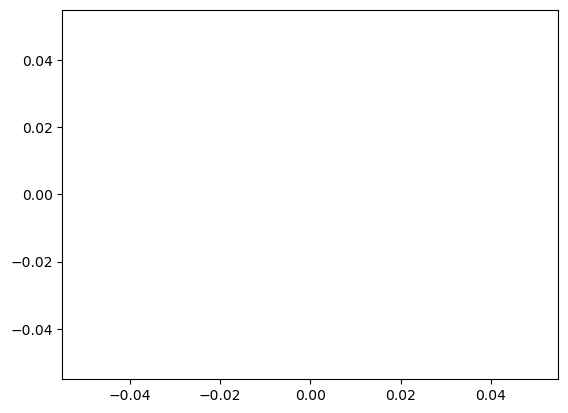

In [200]:
test = timeshifted_df_list[10]
plt.plot(test.index.diff())
#plt.xlim(1, 1450)

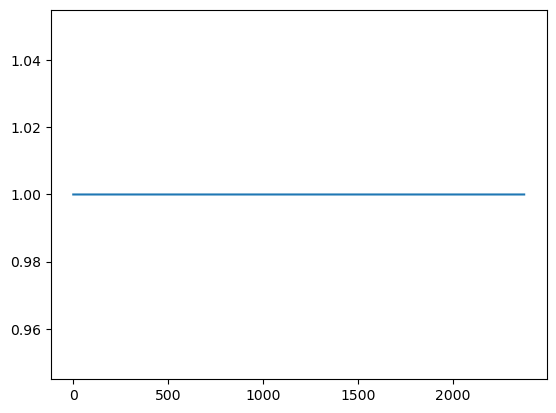

In [201]:
test = timeshifted_df_list[1]
plt.plot(test.index.diff())
#plt.xlim(1, 1450)

In [202]:
testx = restricted_df_list[1].truncate(estimated_starts_x[1], estimated_ends_x[1])

In [203]:
xxx = testx.resample('1s').mean()

<Axes: >

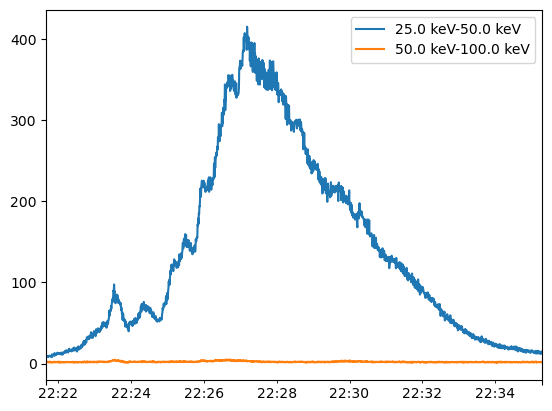

In [204]:
testx.plot()

<Axes: >

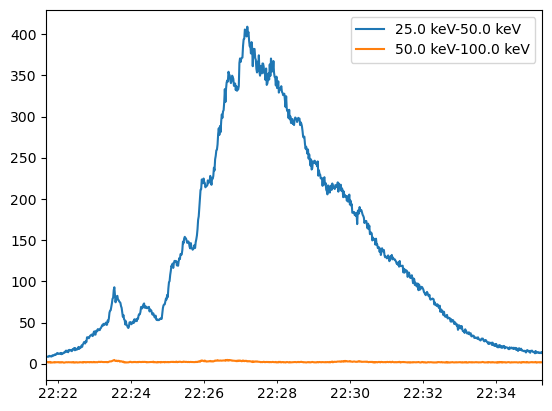

In [205]:
xxx.plot()

In [206]:
# test = restricted_df_list[0].copy()
# test.index = t(test.index)
# test.index = restricted_df_list[0].resample('0.1s')
# test

In [207]:
sci_query = Fido.search(a.Time(flarelist['start_UTC'].iloc[i], 
                                   flarelist['end_UTC'].iloc[i]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
                        #a.stix.DataProduct.sci_xray_spec)
#sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-09-12T06:00:02.000,2024-09-12T12:00:00.000,STIX,L1,SCI,sci-xray-cpd,V02,2409129889
2024-09-12T09:25:18.000,2024-09-12T09:42:43.000,STIX,L1,SCI,sci-xray-cpd,V02,2409128166
2024-09-12T09:41:44.000,2024-09-12T10:06:10.000,STIX,L1,SCI,sci-xray-cpd,V02,2409124745
2024-09-12T10:33:15.000,2024-09-12T10:40:25.000,STIX,L1,SCI,sci-xray-cpd,V02,2409123769
2024-09-12T04:25:00.000,2024-09-12T10:29:59.000,STIX,L1,SCI,sci-xray-spec,V02,2409122231
2024-09-12T04:25:00.000,2024-09-12T10:29:59.000,STIX,L1,SCI,sci-xray-spec,V04,2409122231
2024-09-12T10:24:59.000,2024-09-12T16:29:59.000,STIX,L1,SCI,sci-xray-spec,V02,2409124696
2024-09-12T10:24:59.000,2024-09-12T16:29:59.000,STIX,L1,SCI,sci-xray-spec,V04,2409124696


In [208]:
timeshifted_df_list[0].index

Index([   0.0,    1.0,    2.0,    3.0,    4.0,    5.0,    6.0,    7.0,    8.0,
          9.0,
       ...
       2368.0, 2369.0, 2370.0, 2371.0, 2372.0, 2373.0, 2374.0, 2375.0, 2376.0,
       2377.0],
      dtype='float64', length=2378)

In [209]:
resampled_df_list[0]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-07-22 21:25:24,6.036000,1.76200
2024-07-22 21:25:25,NaN,NaN
2024-07-22 21:25:26,NaN,NaN
2024-07-22 21:25:27,NaN,NaN
2024-07-22 21:25:28,NaN,NaN
...,...,...
2024-07-23 03:29:53,NaN,NaN
2024-07-23 03:29:54,NaN,NaN
2024-07-23 03:29:55,NaN,NaN
2024-07-23 03:29:56,NaN,NaN


In [210]:
timeshifted_df_list[3]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
0.0,0.075520,0.105827
1.0,0.076932,0.099944
2.0,0.071992,0.101121
3.0,0.073403,0.110533
4.0,0.070580,0.115239
...,...,...
2373.0,0.046939,0.094062
2374.0,0.049409,0.090532
2375.0,0.048350,0.088179
2376.0,0.044469,0.075237


In [211]:
x = pd.concat((timeshifted_df_list[0]['25.0 keV-50.0 keV'], timeshifted_df_list[1]['25.0 keV-50.0 keV']), axis=1)
x.shape

(2378, 2)

In [212]:
concat_band1 = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list), axis=1)
concat_band2 = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list), axis=1)
concat_band2_reduced = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list_50100), axis=1)
averaged_shape_flare_2550 = pd.DataFrame(concat_band1.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100 = pd.DataFrame(concat_band2.mean(axis=1), columns=['50.0 keV-100.0 keV'])
averaged_shape_flare_50100_reduced = pd.DataFrame(concat_band2_reduced.mean(axis=1), columns=['50.0 keV-100.0 keV'])

In [213]:
len(normalised_df_list)

44

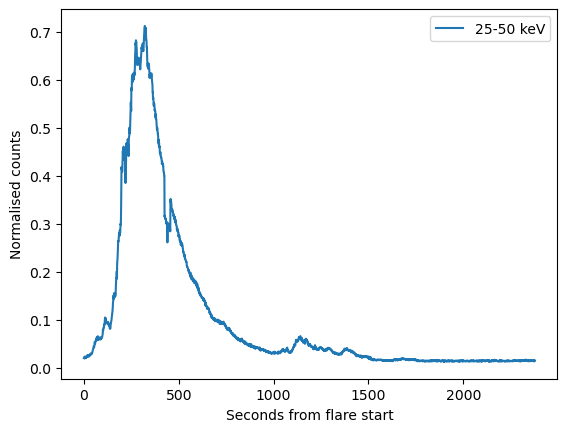

In [214]:
plt.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_2550.png", bbox_inches='tight')

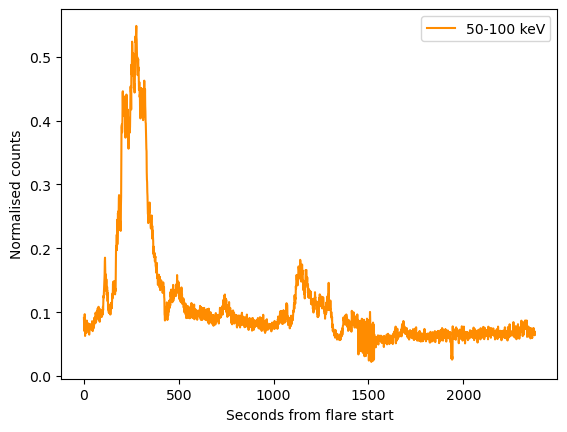

In [215]:
plt.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], label='50-100 keV', color='darkorange')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_50_100.png", bbox_inches='tight')

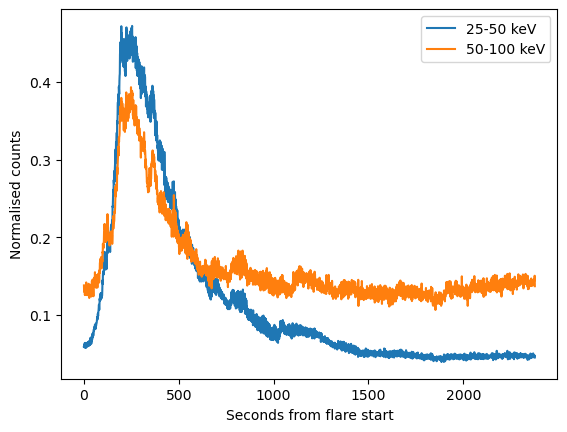

In [141]:
plt.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_bothbands_updated.png", bbox_inches='tight')

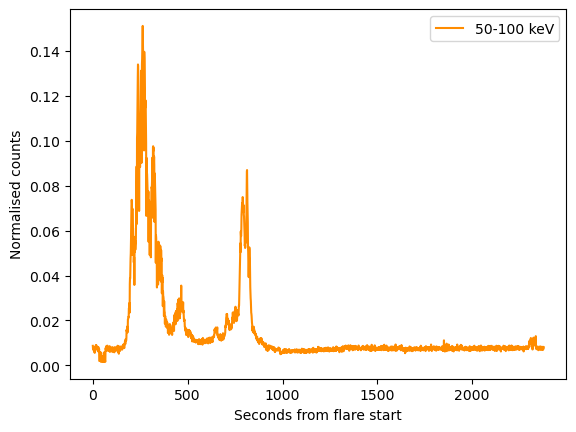

In [142]:
#plt.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.plot(averaged_shape_flare_50100_reduced.index, averaged_shape_flare_50100_reduced['50.0 keV-100.0 keV'], label='50-100 keV', color='darkorange')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_reduced.png", bbox_inches='tight')

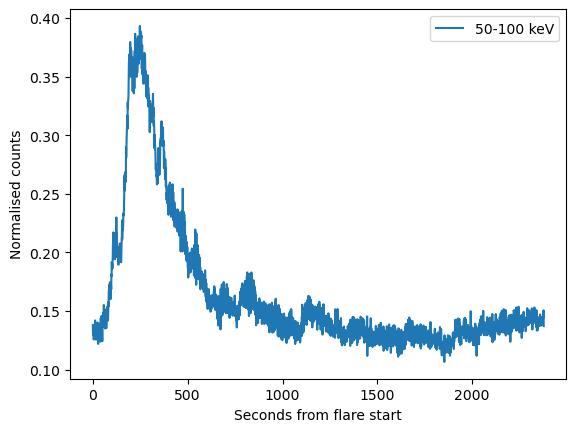

In [143]:
plt.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_50_100.png", bbox_inches='tight')

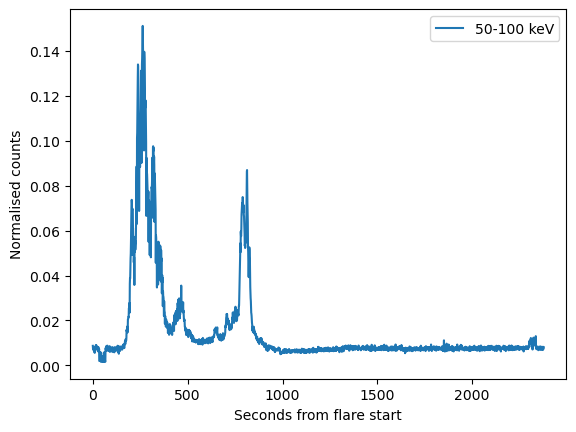

In [144]:
plt.plot(averaged_shape_flare_50100_reduced.index, averaged_shape_flare_50100_reduced['50.0 keV-100.0 keV'], label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_50_100_reduced.png", bbox_inches='tight')

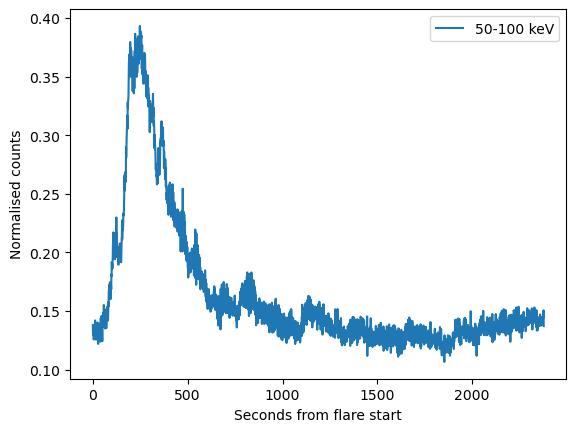

In [145]:
plt.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'], label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_50_100.png", bbox_inches='tight')

In [146]:
mean_avg_flare = pd.concat((averaged_shape_flare_2550, averaged_shape_flare_50100), axis=1)
mean_avg_flare

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
0.0,0.058905,0.138119
1.0,0.058631,0.129807
2.0,0.061640,0.133978
3.0,0.058554,0.137186
4.0,0.063808,0.136987
...,...,...
2373.0,0.047466,0.144675
2374.0,0.048362,0.143789
2375.0,0.047067,0.145334
2376.0,0.047690,0.150560


In [147]:
avg_filtered  = mean_avg_flare.copy()

filtered_2550 = savgol_filter(mean_avg_flare['25.0 keV-50.0 keV'], window_length = 55, polyorder=2)
filtered_50100 = savgol_filter(mean_avg_flare['50.0 keV-100.0 keV'], window_length = 55, polyorder=2)

avg_filtered['25.0 keV-50.0 keV'] = filtered_2550
avg_filtered['50.0 keV-100.0 keV'] = filtered_50100

<Axes: >

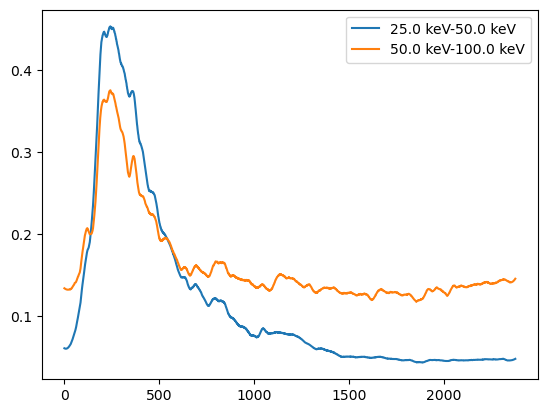

In [148]:
avg_filtered.plot()

In [149]:
half_max = 0.5*np.max(avg_filtered['25.0 keV-50.0 keV'])
half_max_loc = avg_filtered.index[avg_filtered['25.0 keV-50.0 keV']>= half_max][0]

over_half = np.where(avg_filtered['25.0 keV-50.0 keV']>half_max)
end_point = avg_filtered.index[over_half[0][-1]]

fwhm = (end_point-half_max_loc)
fwhm

np.float64(342.0)

In [150]:
restricted_stats_df['FWHM (25-50 keV)'].mean()

np.float64(177.86363636363637)

In [151]:
half_max_50100 = 0.5*np.max(avg_filtered['50.0 keV-100.0 keV'])
half_max_loc_50100 = avg_filtered.index[avg_filtered['50.0 keV-100.0 keV']>= half_max_50100][0]

over_half_50100 = np.where(avg_filtered['50.0 keV-100.0 keV']>half_max_50100)
end_point_50100 = avg_filtered.index[over_half_50100[0][-1]]

fwhm_50100 = (end_point_50100-half_max_loc_50100)
fwhm_50100

np.float64(456.0)

In [152]:
restricted_stats_df['FWHM (50-100 keV)'].mean()

np.float64(154.02941176470588)

In [153]:
test_avg= avg_filtered[np.abs(avg_filtered['25.0 keV-50.0 keV'].diff())>0.0005]
diff_estimated_start = test_avg.index[0]
diff_estimated_end = test_avg.index[-1]
print(diff_estimated_start, diff_estimated_end)

32.0 1243.0


In [154]:
timeshifted_peaks_df_list = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    peak_time = pd.to_datetime(t(restricted_stats_df['peak_time'].iloc[i])).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-1200, 1200)
    timeshifted_peaks_df_list.append(timeshifted_df)
    i+=1

In [155]:
concat_band1_peak = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_peaks_df_list), axis=1)
concat_band2_peak = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_peaks_df_list), axis=1)
averaged_shape_flare_2550_peak = pd.DataFrame(concat_band1_peak.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100_peak = pd.DataFrame(concat_band2_peak.mean(axis=1), columns=['50.0 keV-100.0 keV'])

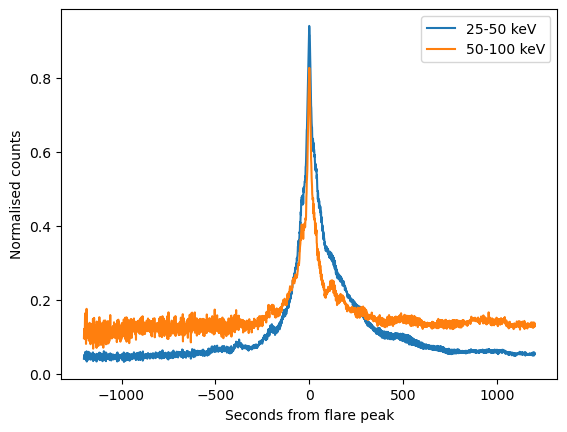

In [156]:
plt.plot(averaged_shape_flare_2550_peak.index, averaged_shape_flare_2550_peak['25.0 keV-50.0 keV'], label='25-50 keV')
plt.plot(averaged_shape_flare_50100_peak.index, averaged_shape_flare_50100_peak['50.0 keV-100.0 keV'], label='50-100 keV')
plt.xlabel('Seconds from flare peak')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_peaks_aligned.png", bbox_inches='tight')

In [157]:
np.where(averaged_shape_flare_2550_peak['25.0 keV-50.0 keV']==np.max(averaged_shape_flare_2550_peak['25.0 keV-50.0 keV']))[0][0]

np.int64(1199)

In [158]:
avg_for_plot = averaged_shape_flare_2550.copy()
avg_for_plot.index = avg_for_plot.index-np.where(averaged_shape_flare_2550['25.0 keV-50.0 keV']==np.max(averaged_shape_flare_2550['25.0 keV-50.0 keV']))[0][0]

avg_for_plot_50100 = averaged_shape_flare_50100.copy()
avg_for_plot_50100.index = avg_for_plot_50100.index-np.where(averaged_shape_flare_50100['50.0 keV-100.0 keV']==np.max(averaged_shape_flare_50100['50.0 keV-100.0 keV']))[0][0]

Text(0.5, 1.0, '25-50 keV')

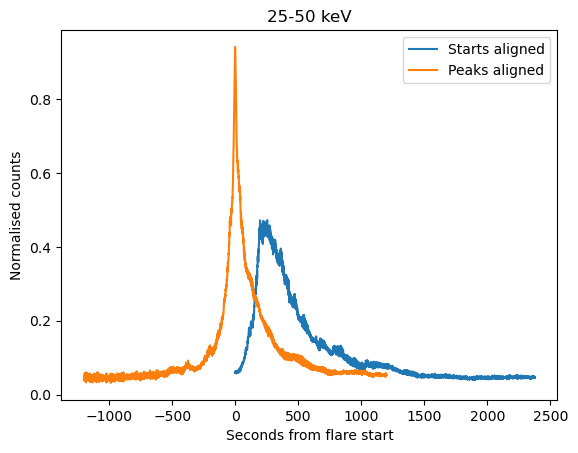

In [159]:
plt.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='Starts aligned')
plt.plot(averaged_shape_flare_2550_peak.index, averaged_shape_flare_2550_peak['25.0 keV-50.0 keV'], label='Peaks aligned')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
# plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_bothbands_updated.png", bbox_inches='tight')

(-300.0, 1200.0)

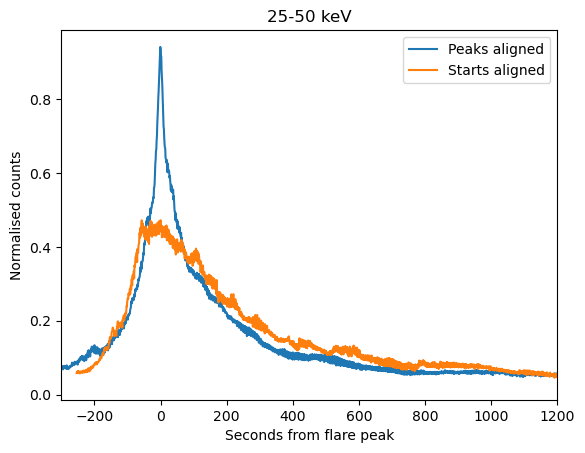

In [160]:
plt.plot(averaged_shape_flare_2550_peak.index, averaged_shape_flare_2550_peak['25.0 keV-50.0 keV'], label='Peaks aligned')
plt.plot(avg_for_plot.index, avg_for_plot['25.0 keV-50.0 keV'], label='Starts aligned')
plt.xlabel('Seconds from flare peak')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
plt.xlim(-300, 1200)
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_peak_vs_start_aligned.png", bbox_inches='tight')

(-250.0, 1200.0)

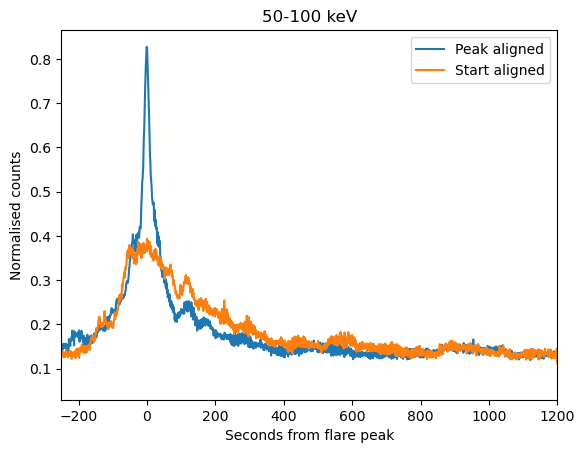

In [161]:
plt.plot(averaged_shape_flare_50100_peak.index, averaged_shape_flare_50100_peak['50.0 keV-100.0 keV'], label='Peak aligned')
plt.plot(avg_for_plot_50100.index, avg_for_plot_50100['50.0 keV-100.0 keV'], label='Start aligned')
plt.xlabel('Seconds from flare peak')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('50-100 keV')
plt.xlim(-250, 1200)
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_peak_vs_start_aligned_50_100.png", bbox_inches='tight')

In [162]:
restricted_df_list_x = []
for i in range(len(df_list_refined)):
    if i not in exclude:
        restricted_df_list_x.append(df_list_refined[i])
len(restricted_df_list)

resampled_df_list_x = []
for df in restricted_df_list_x:
    resampled_df = df.resample('1s').mean()
    resampled_df_list_x.append(resampled_df)

normalised_df_list_x = []
for df in resampled_df_list_x:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list_x.append(normalised_df)

In [171]:
restricted_stats_df_x = filtered_stats_df[~filtered_stats_df.index.isin(exclude)]
flarelist = top100[~top100.index.isin(list(top100.index[exclude])+list(top100.index[bad_diff_full]))]

In [172]:
len(filtered_stats_df)

83

In [173]:
timeshifted_thresholdstarts_df_list = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(restricted_stats_df['start_time'].iloc[i])).round('1s')
    #

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, 2400)
    timeshifted_thresholdstarts_df_list.append(timeshifted_df)
    i+=1

In [174]:
concat_band1_thresholdstarts = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_thresholdstarts_df_list), axis=1)
concat_band2_thresholdstarts = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_thresholdstarts_df_list), axis=1)
averaged_shape_flare_2550_thresholdstarts = pd.DataFrame(concat_band1_thresholdstarts.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100_thresholdstarts = pd.DataFrame(concat_band2_thresholdstarts.mean(axis=1), columns=['50.0 keV-100.0 keV'])

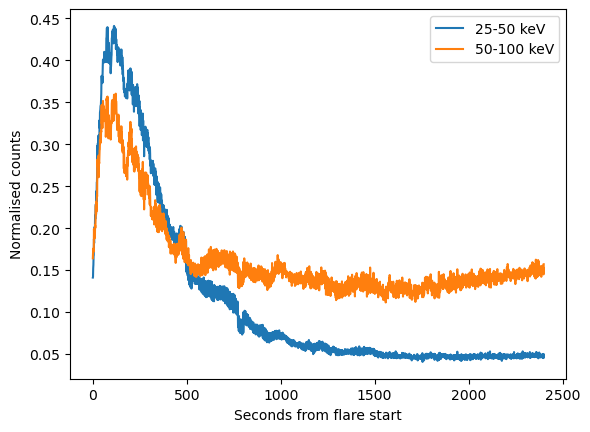

In [175]:
plt.plot(averaged_shape_flare_2550_thresholdstarts.index, averaged_shape_flare_2550_thresholdstarts['25.0 keV-50.0 keV'], label='25-50 keV')
plt.plot(averaged_shape_flare_50100_thresholdstarts.index, averaged_shape_flare_50100_thresholdstarts['50.0 keV-100.0 keV'], label='50-100 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.legend()
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/mean_flare_shape_peaks_aligned.png", bbox_inches='tight')

In [176]:
avg_for_plot_threshold = averaged_shape_flare_2550_thresholdstarts.copy()
avg_for_plot_threshold.index = avg_for_plot_threshold.index-np.where(averaged_shape_flare_2550_thresholdstarts['25.0 keV-50.0 keV']==np.max(averaged_shape_flare_2550_thresholdstarts['25.0 keV-50.0 keV']))[0][0]

avg_for_plot_50100_threshold = averaged_shape_flare_50100_thresholdstarts.copy()
avg_for_plot_50100_threshold.index = avg_for_plot_50100_threshold.index-np.where(averaged_shape_flare_50100_thresholdstarts['50.0 keV-100.0 keV']==np.max(averaged_shape_flare_50100_thresholdstarts['50.0 keV-100.0 keV']))[0][0]

(-300.0, 1200.0)

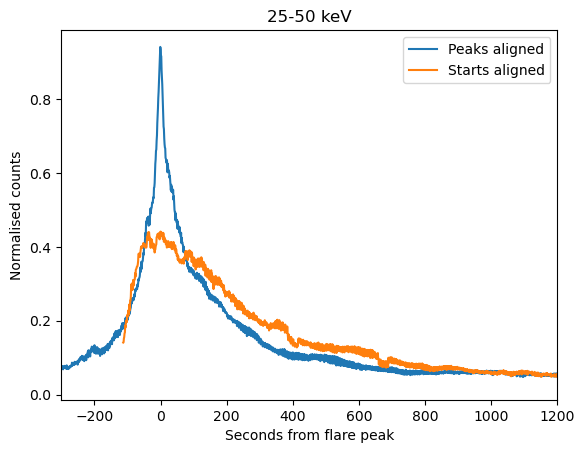

In [177]:
plt.plot(averaged_shape_flare_2550_peak.index, averaged_shape_flare_2550_peak['25.0 keV-50.0 keV'], label='Peaks aligned')
plt.plot(avg_for_plot_threshold.index, avg_for_plot_threshold['25.0 keV-50.0 keV'], label='Starts aligned')
plt.xlabel('Seconds from flare peak')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('25-50 keV')
plt.xlim(-300, 1200)

(-300.0, 1200.0)

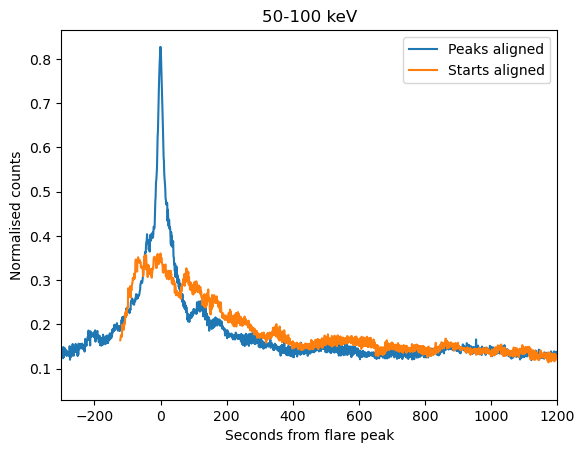

In [170]:
plt.plot(averaged_shape_flare_50100_peak.index, averaged_shape_flare_50100_peak['50.0 keV-100.0 keV'], label='Peaks aligned')
plt.plot(avg_for_plot_50100_threshold.index, avg_for_plot_50100_threshold['50.0 keV-100.0 keV'], label='Starts aligned')
plt.xlabel('Seconds from flare peak')
plt.ylabel('Normalised counts')
plt.legend()
plt.title('50-100 keV')
plt.xlim(-300, 1200)